<a href="https://colab.research.google.com/github/Vaxi444/projet-qualite-soudure_AA/blob/main/td1_ml_sujet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><img src='https://netacad.centralesupelec.fr/img/cs.jpg' width=200></center>

<h6><center>Introduction to Machine Learning</center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center>Tutorial 1: Data preprocessing</center>
<hr style=" border:none; height:3px;">
</h1>


# Introduction

In this tutorial we're going to experiment with synthetic data and real data and learn basic data preprocessing operations with *Scikit-learn*.

<div class="alert alert-block alert-info">

For the most part, the Python code is already written for you. You're invited to **read the code and the comments** to learn how to practice machine learning with *Scikit-learn*. Your instructor will also explain the code.

</div>



# Setup

We import the modules that are commonly used in combination with Scikit-learn.

<div class="alert alert-block alert-warning">
In order to run this notebook, you'll need to install <b>Python 3.5 or later</b>, as well as <b>Scikit-learn 0.20 or later</b>.
</div>

In [ ]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Numpy arrays are used to store training and test data.
import numpy as np

# Pandas is used to manipulate tabular data.
import pandas as pd

# Matplotlib is used to plot graphs.
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
# Style options for plots.
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Ignore useless warnings (see SciPy issue #5998).
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# Convenience function to create display a progress bar.
# Source : https://stackoverflow.com/questions/3173320/text-progress-bar-in-the-console
def print_progress_bar (iteration, total, prefix = '', suffix = '', decimals = 1, length = 100, fill = '█', printEnd = "\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end = printEnd)
    # Print New Line on Complete
    if iteration == total:
        print()

# Saves a figure to a file
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join("./figs", fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Experimenting with synthetic data

Scikit-learn provides the function [*sklearn.datasets.make_regression()*](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html) to generate synthetic data for regression problems.

In the following cell we generate a dataset with **1000 instances** and **1 feature**. The function returns:

* a (1000 $\times$ 1) matrix $X$, with the values of the feature (**independent variable**) for the 1000 instances.

* a (1000 $\times$ 1) vector $y$, with the values of the **dependent variable** (or, **target variable**), the one to predict.

<div class="alert alert-block alert-info">
The value of the parameter <i>random_state</i> is a random number generator seed. When its value is <i>None</i>, each time we run the cell we obtain a different dataset, otherwise we always obtain the same dataset.
</div>

<div class="alert alert-block alert-info">
The matrix $X$ and the vector $y$ are represented as <b>Numpy arrays</b>.
</div>

Text(0.5, 1.0, 'Generated dataset')

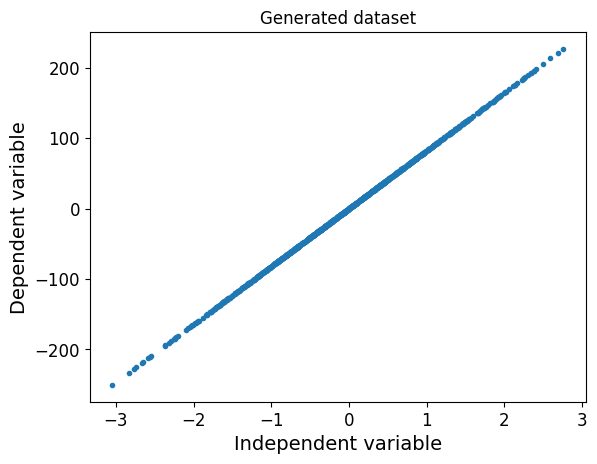

In [ ]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=1000, #number of instances.
    n_features=1,   #number of features.
    random_state=0  #generate the same dataset at each run.
)

# Plot the dataset with Matplotlib
plt.plot(X, y,'.',label='Dataset')
plt.xlabel('Independent variable')
plt.ylabel('Dependent variable')
plt.title('Generated dataset')

The instances form a perfect line, which doesn't make the linear regression problem very interesting. We can add some **noise** to the dataset with the *noise* parameter, as in the following cell.

<div class="alert alert-block alert-info">
The value of the parameter <i>noise</i> is the <b>standard deviation</b> of the Gaussian noise added to the instances (the <b>mean</b> being 0).
</div>

Text(0.5, 1.0, 'Generated dataset')

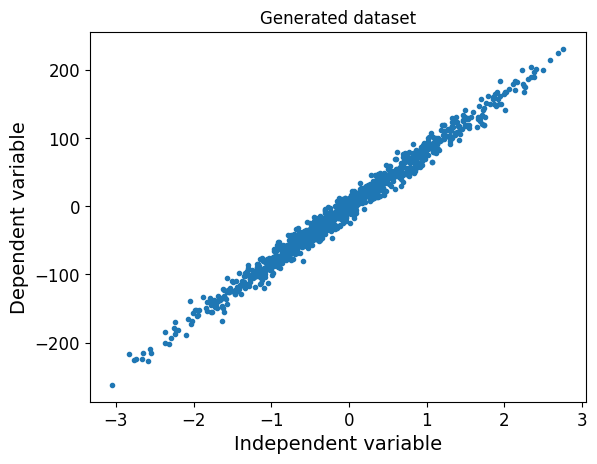

In [ ]:
X, y = make_regression(
    n_samples=1000, #number of instances.
    n_features=1,   #number of features.
    noise = 10,     #standard deviation of the gaussian noise applied to the output.
    random_state=0  #generate the same dataset at each run.
)

# Plot the dataset with Matplotlib
plt.plot(X, y,'.',label='Dataset')
plt.xlabel('Independent variable');
plt.ylabel('Dependent variable')
plt.title('Generated dataset')

In order to train a linear regressor on the generated dataset, we need to split the dataset into a **training set** and a **test set**.
Scikit-learn provides the function [*sklearn.model_selection.train_test_split*](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) that takes in the following parameters:

* The matrix $X$ with the independent variables.
* The vector $y$ with the dependent variable.
* The size of the test set (percentage of the size of the complete dataset).
* A random number generator seed (if we don't specify any, each time we run the cell we get different training/test sets).

The function returns:

* The matrix $X_{train}$ with the **independent variables** of the **training instances**.
* The matrix $X_{test}$ with the **independent variables** of the **test instances**.
* The vector $y_{train}$ with the **dependent variable** of the **training instances**.
* The vector $y_{test}$ with the **dependent variable** of the **test instances**.

<div class="alert alert-block alert-info">
As per convention, we keep 80% of the instances for training and sample out 20% of instances for testing.
</div>

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scikit-learn provides the function [*sklearn.linear_model.SGDRegressor*](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) to solve a linear regression problem by using the **gradient descent** algorithm.

<div class="alert alert-block alert-info">
The plot that you obtain after running the following cell shows the model (in red) that the linear regressor learns from the training data. In this case, the model is a straight line.
</div>


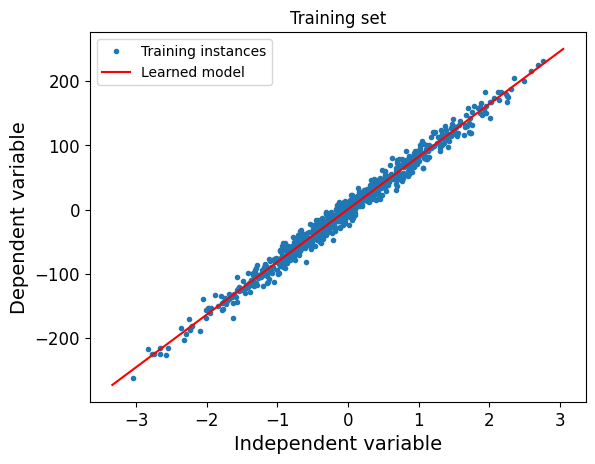

In [ ]:
from sklearn.linear_model import SGDRegressor

# We create an instance of the linear regressor.
lin_reg = SGDRegressor()

# The function fit is used to train the linear regressor on the training data.
# The result is a line with a given intercept and slope.
lin_reg.fit(X_train, y_train)

# The intercept and the slope of the line learned on the training set.
intercept = lin_reg.intercept_[0]
slope = lin_reg.coef_[0]

# Plot the instances of the training set.
plt.plot(X_train, y_train,'.', label='Training instances')

# We plot the line learned from the training set.
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '-r', label="Learned model")

# We write a title and the labels on the axes.
plt.xlabel('Independent variable');
plt.ylabel('Dependent variable')
plt.title('Training set')
plt.legend()

We can use the learned model to make predictions on the test instances. Since we know the true target values of the test instances, we can also measure the **prediction error**.

<div class="alert alert-block alert-info">

The prediction error is measured with the <b>root mean square error (RMSE)</b>

</div>

The prediction error (RMSE) is 9.550836962033616


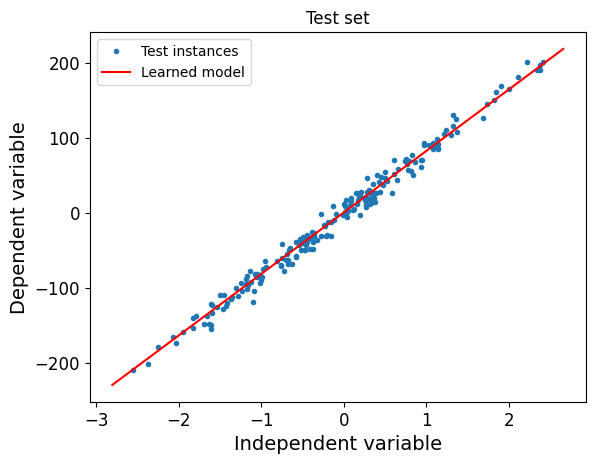

In [ ]:
from sklearn.metrics import mean_squared_error

# We use the function predict to make predictions on the test instances.
predictions = lin_reg.predict(X_test)
# We compute the mean squared error, by comparing
# the predictions with the actual target values
mse = mean_squared_error(y_test, predictions)

# We print the root mean square error.
print("The prediction error (RMSE) is {}".format(np.sqrt(mse)))

# Plot the instances of the test set.
plt.plot(X_test, y_test,'.', label='Test instances')

# We plot the line learned from the training set.
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '-r', label="Learned model")

plt.xlabel('Independent variable');
plt.ylabel('Dependent variable')
plt.title('Test set')
plt.legend()


## Effect of scale

We want to analyze the effect of the **scale of the feature values** on the gradient descent algorithm.
For this purpose:

1. We generate a dataset for linear regression with a high number of features (up to 100,000);

2. We scale the values of these features so that they all have very different scales.

3. We compute the time taken for training a linear regressor for a varying number of features.

<div class="alert alert-block alert-success">
<b>Question 1.</b> Write the code to generate a dataset for linear regression with 1,000 instances and 100,000 features.
</div>

In [ ]:
from sklearn.datasets import make_regression
import matplotlib as mpl
import matplotlib.pyplot as plt

# WRITE THE CODE HERE
X, y = make_regression(
    n_samples = 1000,
    n_features = 100_000,
    noise = 10,
    random_state = 0
)

In the following cell, we define the function *plot_mean_stdev* to plot the **mean** and the **standard deviation** of each feature. We call the function on the generated dataset.

<div class="alert alert-block alert-success">
<b>Question 2.</b> What can you say about the scale of the features?
</div>

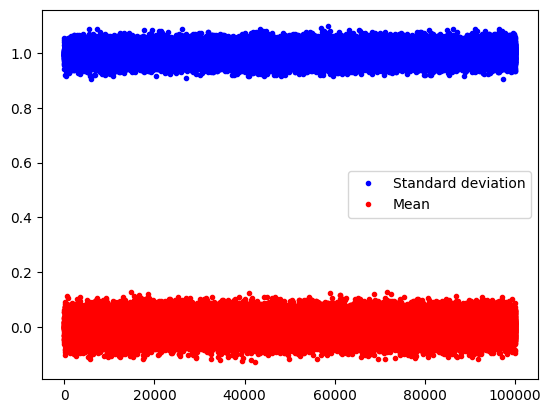

In [ ]:
import numpy as np

def plot_mean_stdev(X, n_features):
    plt.plot([i for i in range(n_features)], np.std(X, axis=0), '.b', label="Standard deviation")
    plt.plot([i for i in range(n_features)], np.mean(X, axis=0), '.r', label="Mean")
    plt.legend()

plot_mean_stdev(X, 100000)

We **rescale the features** so that they have values with **very different scales**.

In [ ]:
import random
n_features = 100_000
# For each feature, we rescale their values so that their minimum value
# is between -100000 and 10000 and their maximum value is between 20000, 100000
for i in range(n_features):
    X[:, i] = np.interp(X[:, i], (X[:, i].min(), X[:, i].max()), \
                        (random.randint(-100000, 10000), random.randint(20000, 100000)))

In the following cell, we **train a linear regressor** with **varying number of features** and we record the training times.
As you can see, training slows down considerably while we increase the number of features.

In [ ]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

# We save here the training time for varying number of features.
training_times_unscaled = []

for i in range(1, 6):
    print("Training with {} features".format(10**i))
    X_train, X_test, y_train, y_test = train_test_split(X[:, :10**i], y, test_size=0.2, random_state=42)
    lin_reg = SGDRegressor()
    start_time = time.time()
    # We train the linear regressor
    lin_reg.fit(X_train, y_train)
    training_time = time.time() - start_time
    training_times_unscaled.append(training_time)
    print("Training time --- {} seconds ---\n".format(training_time))

Training with 10 features
Training time --- 0.00760340690612793 seconds ---

Training with 100 features
Training time --- 0.02481222152709961 seconds ---

Training with 1000 features
Training time --- 0.08616971969604492 seconds ---

Training with 10000 features
Training time --- 1.1107745170593262 seconds ---

Training with 100000 features
Training time --- 15.783438682556152 seconds ---



In the following cell, we **standardize** the features in the training set, so that they all have 0 mean and unit standard deviation, **before** training the linear regressor.


To standardize the features, we use the class [*sklearn.preprocessing.StandardScaler*](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

***StandardScaler* is used on variables that have a Gaussian distribution.**

<div class="alert alert-block alert-info">
In the following cell, the training time also accounts for the time of scaling the features.
</div>

Training with 10 features
Training time --- 0.004773139953613281 seconds ---

Training with 100 features
Training time --- 0.02380061149597168 seconds ---

Training with 1000 features
Training time --- 1.2005517482757568 seconds ---

Training with 10000 features
Training time --- 0.282193660736084 seconds ---

Training with 100000 features
Training time --- 7.1001832485198975 seconds ---



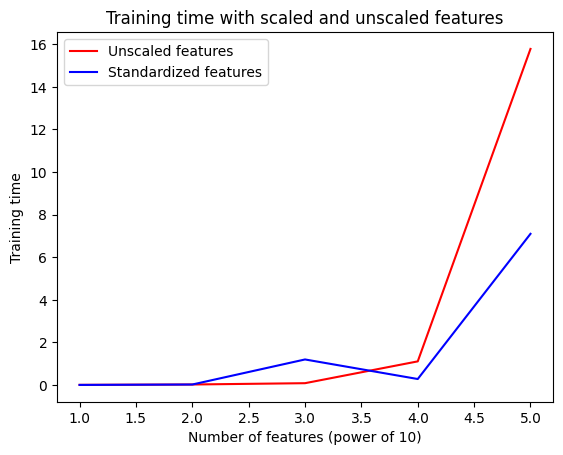

In [ ]:
from sklearn.preprocessing import StandardScaler

# We save here the training time for varying number of features.
training_times_standardized = []

for i in range(1, 6):
    print("Training with {} features".format(10**i))
    X_train, X_test, y_train, y_test = train_test_split(X[:, :10**i], y, test_size=0.2, random_state=42)
    lin_reg = SGDRegressor()

    start_time = time.time()

    # We create an instance of the class StandardScaler
    scaler = StandardScaler()
    # We scale the training instances.
    X_train = scaler.fit_transform(X_train)

    # We train the linear regressor
    lin_reg.fit(X_train, y_train)
    training_time = time.time() - start_time
    training_times_standardized.append(training_time)
    print("Training time --- {} seconds ---\n".format(training_time))

# We plot the training times with unscaled and standardized features.
plt.plot([1, 2, 3, 4, 5], training_times_unscaled, '-r', label="Unscaled features")
plt.plot([1, 2, 3, 4, 5], training_times_standardized, '-b', label="Standardized features")

plt.xlabel('Number of features (power of 10)');
plt.ylabel('Training time')
plt.title('Training time with scaled and unscaled features')
plt.legend()

When the variable does not have a Gaussian distribution, an alternative to *StandardScaler* is *MinMaxScaler* that transforms the data so that they fall in the interval $[0, 1]$; if you want the data to fall in a different interval (e.g., [-1, 1]) you can use the option *feature_range* of *MinMaxScaler*.


<div class="alert alert-block alert-success">
<b>Question 3.</b> Write the code to analyze the training time (as we did in the previous cell) when using <b>min-max scaling</b> (set the interval to [-1, 1]) with a varying number of features. Use the class
<a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html" target="_blank"><i>sklearn.preprocessing.MinMaxScaler</i></a>. Comment on the result.
</div>



Training with 10 features
Training time --- 0.003812074661254883 seconds ---

Training with 100 features
Training time --- 0.01238703727722168 seconds ---

Training with 1000 features
Training time --- 0.47830843925476074 seconds ---

Training with 10000 features
Training time --- 10.67093801498413 seconds ---

Training with 100000 features
Training time --- 15.083195686340332 seconds ---



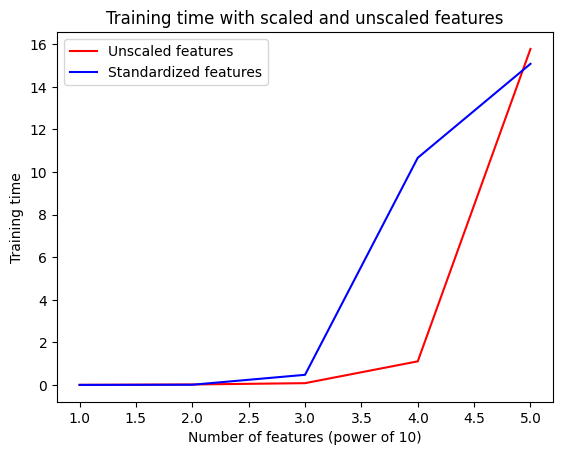

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# WRITE THE CODE HERE
training_times_standardized = []

for i in range(1,6):
  print("Training with {} features".format(10**i))
  X_train, X_test, y_train, y_test = train_test_split(X[:, :10**i], y, test_size=0.2, random_state = 42)
  line_reg = SGDRegressor()
  start_time = time.time()
  scaler = MinMaxScaler()

  #scale
  X_train = scaler.fit_transform(X_train)
  line_reg.fit(X_train, y_train)
  training_time = time.time() - start_time
  training_times_standardized.append(training_time)
  print("Training time --- {} seconds ---\n".format(training_time))

# We plot the training times with unscaled and standardized features.
plt.plot([1, 2, 3, 4, 5], training_times_unscaled, '-r', label="Unscaled features")
plt.plot([1, 2, 3, 4, 5], training_times_standardized, '-b', label="Standardized features")

plt.xlabel('Number of features (power of 10)');
plt.ylabel('Training time')
plt.title('Training time with scaled and unscaled features')
plt.legend()


## Using Pipelines

Scikit-learn provides a powerful object to define a sequence of transformations that is called a **pipeline**. A pipeline is a sequence of operations that is applied on a dataset.
Each object of a pipeline is a **transformer** that executes a specific transformation (e.g., standardization) on the input data. Optionally, the last object of the pipeline can be an **estimator**, a machine learning algorithm that is applied on the transformed dataset.

In the following cell, we define a pipeline with two objects:

1. An instance of the class **StandardScaler** (a **transformer**).
2. An instance of the class **SGDRegressor** (an **estimator**).

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Each object of the pipeline is identified by a key ('std_scaler', 'linreg').
# You can use any value as the key of an object in the pipeline
pipeline =  Pipeline([
    ('std_scaler', StandardScaler()),
    ('linreg', SGDRegressor())
])

The **advantage** of using a pipeline is that we define  all the transformations once and we can apply them on different datasets, which results in a shorter, more readable code.
Moreover, when training and testing a model, a pipeline ensures that we apply the **exact same transformations** on both the training and test set.

In the following cell, we obtain a training and test set from the synthetic data and we apply the pipeline on the training set.

<div class="alert alert-block alert-success">
<b>Question 4.</b> What is the effect of calling the function <i>fit</i> on the pipeline?
</div>

In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=1000, n_features=20, noise=10, random_state=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('std_scaler', StandardScaler()), ('linreg', SGDRegressor())])

<div class="alert alert-block alert-success">
<b>Question 5.</b> Write the code that uses the pipeline to transform the test instances and uses the learned linear regressor to make predictions. Estimate the RMSE.
</div>

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


# We use the function predict to make predictions on the test instances.
predictions = pipeline.predict(X_test)
# We compute the mean squared error, by comparing
# the predictions with the actual target values
mse = mean_squared_error(y_test, predictions)

# We print the root mean square error.
print("The prediction error (RMSE) is {}".format(np.sqrt(mse)))

The prediction error (RMSE) is 9.899146714700287


<div class="alert alert-block alert-info">
You should always use pipelines when training/testing machine learning algorithms on preprocessed data.
</div>

## Handling missing data

Virtually any real dataset contains some amount of **missing data**, where one or more features have missing values. Generally, machine learning algorithms **don't like** missing values, which is why we need to deal with them before training.


When only a handful of instances present some missing values, we can safely remove them from the dataset. This procedure is called **listwise deletion**.
However, listwise deletion is a **risky heuristics** that should be used with caution, as it might severely affect the distribution of the features and the regression coefficients.

Let $X$ be the matrix representing a dataset and $X_{j}$ be a feature with missing values (a column of $X$). We can identify three categories of missing data:

1. **Missing completely at random (MCAR).** The probability that a value of $X_j$ is missing does **not** depend on the values of the other features, whether they are missing or not.

$$P(X_j\ missing | X) = P(X_j\ missing)$$

2. **Missing at random (MAR).** The probability that a value of $X_j$ is missing depends on the **observed values** $X_{observed}$ (not the missing values) of the other features.

$$P(X_j\ missing | X) = P(X_j\ missing | X_{observed})$$

3. **Missing not at random (MNAR).** The probability that a value of $X_j$ is missing depends on the **missing values** $X_{missing}$ of the other features (or a missing feature).

$$P(X_j\ missing | X) = P(X_j\ missing | X_{missing})$$

In the following cell, we define three functions *mcar()*, *mar()* and *mnar()* in order to generate some missing values of the three categories respectively in a given dataset. In each function, we specify the index of the feature for which we intend to generate missing values, as well as the ratio of missing values.

In [ ]:
import random
import math

def mcar(X, missing_feature, missing_ratio=0.05):
    '''Generates missing values of category MCAR in the given dataset for the specified feature.

    The function randomly picks some values in the column of X with index missing_feature and replaces
    them with NaN (indicating a missing value).
    Missing values are selected completely at random, their choice doesn't depend on the other
    values of X.

    Parameters
    ----------
        X : numpy array (matrix)
            A dataset.
        missing_feature : int
            The index of the column of X where we want to generate some missing values.
        missing_ratio : float
            A value between 0 and 1, specifying the ratio of missing values (over the total number of instances).

    Returns
    --------
        Numpy array (matrix).
            The input matrix X with missing values for the specified feature.

    '''
    n_instances = X.shape[0]
    X_mcar = X.copy()
    mcar = math.floor(n_instances * missing_ratio)
    idx_mcar = [True]*mcar + [False]*(n_instances - mcar)
    random.shuffle(idx_mcar)
    X_mcar[idx_mcar, missing_feature] = float('nan')
    return X_mcar


def find_threshold(Xj, ratio=0.05):
    '''Auxiliary function used by functions mar() and mnar().

    Determines the threshold value in array Xj
    such that the number of instances of Xj below that value over the total number of instances
    matches the given ratio.

    Parameters
    ----------
        Xj : numpy array.
            A column of a matrix X.
        ratio : float
            The ratio of the instances of Xj that have a value below
            the determined threshold.

    Returns
    -------
        float
            The threshold value.

    '''
    Xj_sorted = np.sort(Xj, axis=None)
    return Xj_sorted[math.ceil(Xj_sorted.shape[0] * ratio)]


def mar(X, missing_feature, influencing_feature, missing_ratio=0.05):
    '''Generates missing values of category MAR in the given dataset for the specified feature.

    The function sets the missing_feature to NaN (indicating a missing value)
    for all the instances such that the influencing_feature has
    a value below a certain threshold.

    Missingness of values in themissing_feature
    depends on the observed values of influencing_feature.


    The threshold is automatically determined to match the given missing_ratio.

    Parameters
    ----------
        X : numpy array (matrix)
            A dataset.
        missing_feature : int
            The index of the column of X where we want to generate some missing values.
        influencing_feature : int
            The index of the column of X that influences the missingness in missing_feature.
        missing_ratio : float
            A value between 0 and 1, specifying the ratio of missing values (over the total number of instances).

    Returns
    --------
        Numpy array (matrix).
            The input matrix X with missing values for the specified feature.

    '''
    X_mar = X.copy()
    n_instances = X_mar.shape[0]
    n_features = X_mar.shape[1]
    threshold = find_threshold(X_mar[:, influencing_feature], missing_ratio)
    X_mar[X_mar[:, influencing_feature]<=threshold, missing_feature] = float('nan')
    return X_mar

def mnar(X, missing_feature, missing_ratio=0.05):
    '''Generates missing values of category MNAR in the given dataset for the specified feature.

    The function sets the missing_feature to NaN (indicating a missing value)
    for all the instances such that the missing_feature has
    a value below a certain threshold.

    Missingness of values of missing_feature
    depends on the missing values of missing_feature.
    For some unknown reason, values below a certain threshold are not recorded.

    The threshold is automatically determined to match the given missing_ratio.

    Parameters
    ----------
        X : numpy array (matrix)
            A dataset.
        missing_feature : int
            The index of the column of X where we want to generate some missing values.
        missing_ratio : float
            A value between 0 and 1, specifying the ratio of missing values (over the total number of instances).

    Returns
    --------
    Numpy array (matrix)
        The input matrix X with missing values for the specified feature.

    '''
    X_mnar = X.copy()
    n_instances = X_mnar.shape[0]
    n_features = X_mnar.shape[1]
    threshold = find_threshold(X_mnar[:, missing_feature], missing_ratio)
    X_mnar[X_mnar[:, missing_feature]<=threshold, missing_feature] = float('nan')
    return X_mnar

We want to assess the effect of missing data on a regression problem. In particular, we want to see how predictions on a test set are influenced when missing data occur in the training set.

Let's first define a convenience function *generate_dataset()* that creates a dataset with the function *make_regression()*, split it into a training and test set and creates four versions of the training set: one with complete data, the others with missing data of each category.

In [ ]:
NO_MISSING = "NO_MISSING"
MCAR = "MCAR"
MAR = "MAR"
MNAR = "MNAR"

def generate_dataset(n_samples=1000, n_features=10, noise=20, missing_feature=1, \
                     influencing_feature=2, missing_ratio=0.05):

    '''Generates a new regression problem (with and without missing values).

    The function generates a dataset, split it into a training (80% of the instances)
    and test set  and returns four versions
    of the training set: one with no missing values, the other with missing values, one for each category
    (MCAR, MAR and MNAR).

    Parameters
    ----------
        n_samples : int
            Number of instances in the dataset (default: 1000).
        n_features : int
            Number of features in the dataset (default: 10)
        noise : int
            The standard deviation of the noise added to the generated instances (default: 20)
        missing_feature : int
            The index of the feature that will contain the missing values (default: 1).
        influencing_feature : int
            The index of the feature that determines the missingness in the missing_feature (default:2).
            This is used to generate MAR missing values.
        missing_ratio: float
            The ratio (values between 0 and 1)
            of missing values over the total number of instances (default: 0.05).

    Returns
    -------
        A tuple (training_sets, X_test, y_test)
            - The first item of the tuple (training_sets) is a Python dictionary with four elements.
                training_set[key] (with key having values "NO_MISSING", "MCAR", "MAR", "MNAR")
                is a tuple (X_train, y_train), representing a training set.
            - The second item of the tuple is X_test.
            - The third item of the tuple is y_test.

    '''

    X, y = make_regression(n_samples=n_samples, n_features=n_features, noise=noise)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    training_sets = {}

    # Generates the training sets with missing data, one for each category of missing data.
    X_train_mcar = mcar(X_train, missing_feature, missing_ratio=missing_ratio)
    X_train_mar = mar(X_train, missing_feature, influencing_feature, missing_ratio=missing_ratio)
    X_train_mnar = mnar(X_train, missing_feature, missing_ratio=missing_ratio)

    training_sets[NO_MISSING] = (X_train, y_train)
    training_sets[MCAR] = (X_train_mcar, y_train)
    training_sets[MAR] = (X_train_mar, y_train)
    training_sets[MNAR] = (X_train_mnar, y_train)

    return (training_sets, X_test, y_test)

Several strategies exist to handle missing values. We now apply them on the synthetic datasets to see how they behave.

### Listwise deletion

Perhaps the easiest way to handle missing data is to...ignore them! In other words, we simply drop from the training set the instances that have missing values. This strategy is called **listwise deletion**.

We first define a function *dropnan()* that drops the instances with missing values from a dataset.

In [ ]:
def dropnan(X, y, missing_feature):
    '''Drops the instances that have a missing value for the given feature.

    The input dataset (X, y) is not modified. A new dataset is created and returned.

    Parameters
    ----------
        X : numpy array (matrix).
            A dataset. Each row corresponds to an instance, each column to a feature.
        y : numpy array.
            The vector with the target values for each instance.
        missing_feature : int
            The index of the column of X that corresponds to the feature with missing values.

    Returns
    -------
        A tuple.
            A tuple (X_nomissing, y_nomissing) that corresponds to the input dataset (X, y) without the instances
            with missing values.
    '''
    X_nomissing = X.copy()
    y_nomissing = y.copy()
    y_nomissing = np.delete(y_nomissing, np.argwhere(np.isnan(X_nomissing[:, missing_feature])), axis=0)
    X_nomissing = X_nomissing[~np.isnan(X_nomissing).any(axis=1)]
    return (X_nomissing, y_nomissing)

Then we write a function *listwise_deletion()* that takes in the training sets returned by the function *generate_dataset()* and uses the function *dropnan()* to remove the instances with missing values.

In [ ]:
def listwise_deletion(training_sets, missing_feature):
    '''Removes the instances with missing values in the specified missing_feature from the given
    training sets.

    Parameters
    ----------
        training_sets : dictionary.
            The training sets returned by the function generate_dataset()
        missing_feature : int
            The index of the feature with missing values.

    Returns
    -------
        Dictionary.
            The input training sets without the instances with missing values.
    '''
    training_sets_listwise = {}
    for key, value in training_sets.items():
        training_sets_listwise[key] = dropnan(value[0], value[1], missing_feature)
    return training_sets_listwise

Then we define a function *test_linear_regression()* that trains a linear regression model on the training sets and returns the prediction errors on the test set.

In [ ]:
def test_linear_regression_models(training_sets, X_test, y_test):

    ''' Trains linear regression models on the given training sets and returns the prediction errors on the
    given test set.

    Parameters
    ----------
        training_sets : A dictionary.
            The training sets. Each item of the dictionary is of the form (key, training_set), where
            training_set is a tuple (X_train, y_train).
        X_test : Numpy array (matrix).
            The features of the test set.
        y_test : Numpy array (vector).
            The target values of the test set.

    Returns
    -------
        A dictionary.
            The predictions errors on the test set of the trained models.
            Each item of the dictionary is of the form (key, error), where key is one of the
            keys of the input dictionary training_sets and error is the prediction error (RMSE)
            of the model on the test set.

    '''

    prediction_errors = {}

    for key, value in training_sets.items():
        linreg = SGDRegressor()
        linreg.fit(value[0], value[1])
        predictions = linreg.predict(X_test)
        prediction_errors[key] = mean_squared_error(y_test, predictions)

    return prediction_errors

Finally, we write a function *test_listwise_deletion()* that:

1. Generates a certain number of regression problems with missing values (MCAR, MAR and MNAR) by using the function *generate_dataset()*,

2. Applies listwise deletion on each training set and evaluates the prediction errors on the test set.

3. The predictions errors are then averaged over the number of regression problems. If the number of regression problems is high (e.g., 10000), we can get a good estimate of the prediction errors in the different cases.

In [ ]:
def test_listwise_deletion(n_datasets=10000, n_samples=1000, n_features=10, noise=20, \
                           missing_feature=1, influencing_feature=2, missing_ratio=0.05):

    '''Generates n_datasets with n_samples with complete and missing data for each category (MCAR, MAR, MNAR).
    For each dataset, compute the prediction error of a linear regression model trained on the training sets with
    complete and missing data (after listwise deletion). Print the prediction error averaged over the number of
    datasets.

    Parameters
    ----------
        n_datasets : int
            The number of generated datasets (default: 10000).
        n_samples : int
            The number of instances in each dataset (default: 1000).
        n_features : int
            The number of features in each dataset (default: 10).
        noise : int
            The standard deviation of the noise added to the generated instances.
        missing_feature : int
            The index of the feature that will contain missing data.
        influencing_feature : int
            The index of the feature that determines the missingness in the missing_feature (default:2).
            This is used to generate MAR missing values.
        missing_ratio: float
            The ratio (values between 0 and 1)
            of missing values over the total number of instances (default: 0.05).

    '''

    # The prediction errors averaged over the generated datasets.
    average_prediction_errors = {}

    progress = 0

    # Display a progress bar
    print_progress_bar(progress, int(n_datasets/100), prefix = 'Progress:', suffix = 'Complete', length = 50)

    # Sample n_datasets
    for i in range(n_datasets):

        # Generate a dataset with training sets with complete and missing values.
        training_sets, X_test, y_test = generate_dataset(n_samples=n_samples, n_features=n_features, noise=noise, \
                                                         missing_feature=missing_feature, influencing_feature=influencing_feature, \
                                                         missing_ratio=missing_ratio)

        # Remove the instances with missing values from the training sets.
        training_sets = listwise_deletion(training_sets, missing_feature)

        # Test the prediction errors of the regression models trained on the training sets.
        prediction_errors = test_linear_regression_models(training_sets, X_test, y_test)

        # Update the count of prediction errors in order to compute the average.
        for key, value in prediction_errors.items():
            if key not in average_prediction_errors :
                average_prediction_errors[key] = value
            else:
                average_prediction_errors[key] += value

        # Update the progress bar
        if i % int(n_datasets/100) == 0:
            progress += 1
            print_progress_bar(progress, int(n_datasets/100), prefix = 'Progress:', suffix = 'Complete', length = 50)

    # Compute the average of the prediction errors.
    for key in average_prediction_errors.keys():
        average_prediction_errors[key] /= n_datasets

    print("\nPrediction error with no missing data {}".format(average_prediction_errors[NO_MISSING]))
    print("Prediction error with MCAR DATA {}".format(average_prediction_errors[MCAR]))
    print("Prediction error with MAR DATA {}".format(average_prediction_errors[MAR]))
    print("Prediction error with MNAR DATA {}".format(average_prediction_errors[MNAR]))

<div class="alert alert-block alert-success">
<b>Question 6.</b> Run the following cell that calls the function <i>test_listwise_deletion()</i> with <i>n_samples</i> = 1000 and <i>missing_ratio</i> = 0.7 (70% of the training instances will have a missing value). What can you say about the prediction errors in the different cases?

1. Call the function <i>test_listwise_deletion()</i> with <i>n_samples</i> = 1000 and <i>missing_ratio</i> = 0.2. Comment on the prediction errors in the different cases.

2. Call the function <i>test_listwise_deletion()</i> with <i>n_samples</i> = 5000 and <i>missing_ratio</i> = 0.7. Comment on the prediction errors in the different cases.
    
</div>

In [ ]:
test_listwise_deletion(n_samples=1000, missing_ratio=0.7, noise=20)

### Univariate feature imputation

A better alternative to listwise deletion is the **imputation** of missing values; that is, missing values are determined (or, **imputed**) by using the observed values in the dataset.

One way to impute the missing values of the $i$-th feature is to use the observed values of the $i$-th feature itself; this is called **univariate simple imputation**.

<div class="alert alert-block alert-info">
Sklearn provides class <a href="https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html" target="_blank">sklearn.impute.SimpleImputer</a> for univariate feature imputation.
</div>

Different **imputation strategies** exist. One possibility is to replace the missing values of the $i$-th feature with the **mean** of the observed values of the $i$-th feature; other strategies use the **median**, the **most frequent value** or a **constant value**. While the first two can only be used for numeric values, the latter can be used with categorical values too.

The code in the following cell:

1. Generates a regression problem with 1000 instances and 10 features.

2. Generates some missing data (MCAR) in the feature with index 1 (*missing ratio* = 0.7).

3. Prints mean and standard deviation of the observed values of feature 1.

4. Prints the Pearson correlation coefficient between the feature 1 and the target variable y.

<div class="alert alert-block alert-info">

Pearson’s correlation coefficient $r$ is a statistical measure of the strength of a linear relationship between two features $X$ and $Y$. It is defined by the following formula:

$$r_{X, Y} = \frac{cov(X, Y)}{\sigma_X \sigma_Y}$$

where:

* $cov(X, Y)$ is the **covariance**.
* $\sigma_X$ is the **standard deviation** of $X$.
* $\sigma_Y$ is the **standard deviation** of $Y$.

By definition, $-1 \leq r \leq 1$.

* Positive values denote positive linear correlation.

* Negative values denote negative linear correlation.

* A value of 0 denotes no linear correlation.

* The stronger the value is to 1 or -1, the stronger the linear correlation.

**Caution.** The existence of a strong correlation between $X$ and $Y$ **does not imply** a causal link between the features.

We can describe the strength of the correlation using the guide suggested by Evans in his book *Straightforward statistics for the behavioral sciences* (1996):

* $0 \leq |r| \leq 0.19$: very weak correlation.

* $0.2 \leq |r| \leq 0.39$: weak correlation.

* $0.4 \leq |r| \leq 0.59$: moderate correlation.

* $0.6 \leq |r| \leq 0.79$: strong correlation.

* $0.8 \leq |r| \leq 1$: very strong correlation.


**Source**: https://www.statstutor.ac.uk/resources/uploaded/pearsons.pdf

</div>

<div class="alert alert-block alert-success">
<b>Question 7.</b>
Compare mean, standard deviation, the correlation coefficients and the histograms of the observed and imputed values.
</div>

Mean (observed values): 0.028174231377896215
Standard deviation (observed values): 1.0265009034561796
Pearson correlation coefficient (observed values): 0.11636869660328379


/tmp/ipython-input-3518281209.py:2: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


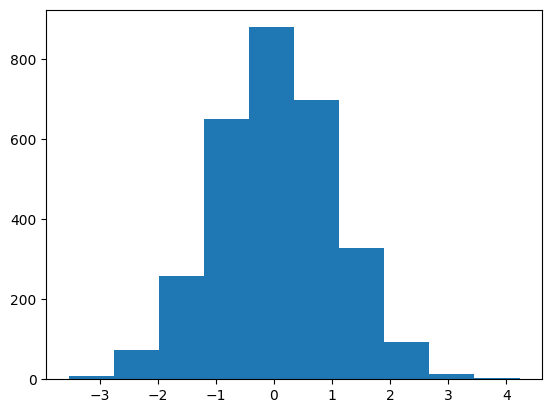

Mean (imputed values): 0.02817423137789616
Standard deviation (imputed values): 0.5622377001223823
Pearson correlation coefficient (imputed values): 0.06328686271972919


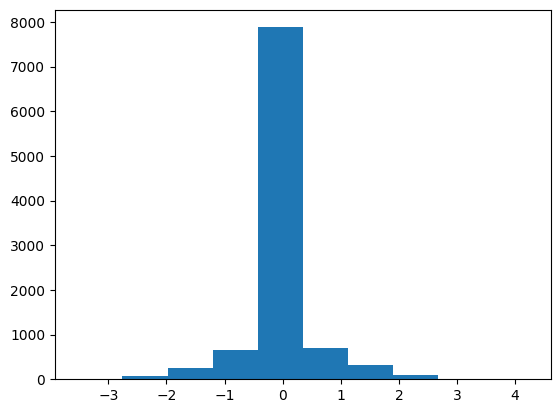

In [ ]:
from sklearn.impute import SimpleImputer
from scipy.stats.stats import pearsonr

# Generate a dataset.
X, y = make_regression(n_samples=10000, n_features=10, noise=20)

# Generate some missing values in feature 1.
X = mcar(X, 1, missing_ratio=0.7)

# We drop the instances with missing values in feature 1.
# This way, we can compute some statistics on the observed values only.
X_nomissing, y_nomissing = dropnan(X, y, 1)

# Compute the Pearson correlation coefficient between the values of feature 1 and
# the target variable y. The function pearsonr returns  the correlation coefficient
# itself and the p_value, indicating the statistical significance of the correlation.
correlation_coefficient, pvalue = pearsonr(X_nomissing[:, 1], y_nomissing)

# Print mean, standard deviation and correlation coefficient on the observed values.
print("Mean (observed values): {}".format(np.mean(X_nomissing[:, 1])))
print("Standard deviation (observed values): {}".format(np.std(X_nomissing[:, 1])))
print("Pearson correlation coefficient (observed values): {}".format(correlation_coefficient))

# Show the histogram of the values of feature 1.
plt.hist(X_nomissing[:, 1])
plt.show()

# Instantiate a transformer for mean imputation.
imp_mean = SimpleImputer(strategy='mean')

# Transforms X so that the missing values are determined by mean imputation.
# The "fit" part is used to compute the mean of the values in X[:, 1]
X_mean = imp_mean.fit_transform(X)

correlation_coefficient, p_value = pearsonr(X_mean[:, 1], y)

print("Mean (imputed values): {}".format(np.mean(X_mean[:, 1])))
print("Standard deviation (imputed values): {}".format(np.std(X_mean[:, 1])))
print("Pearson correlation coefficient (imputed values): {}".format(correlation_coefficient))

plt.hist(X_mean[:, 1])
plt.show()

An object of the class *SimpleImputer* is a transformer and, as such, can be used in a pipeline. The example in the following cell creates a pipeline that replaces the missing values with the mean, standardizes the values and then applies a linear regressor.
The pipeline is used on the training and test set of a generated dataset.

<div class="alert alert-block alert-success">

Read the code below. You'll use the same schema (creation of a pipeline, call of the function $fit$ on the pipeline with the training data, call of the function $predict$ on the pipeline with test data) whenever you'll need to train and evaluate a machine learning model.

</div>

In [ ]:
# Creates the pipeline.
pipeline =  Pipeline([
    ('mean_imputer', SimpleImputer(strategy='mean')),
    ('std_scaler', StandardScaler()),
    ('linreg', SGDRegressor())
])

# Generate a dataset.
X, y = make_regression(n_samples=10000, n_features=10, noise=10)

# Obtain a training and test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Generate some missing values in the training set.
X_train = mcar(X_train, 1, missing_ratio=0.2)

# Train the linear regression model by using the pipeline.
pipeline.fit(X_train, y_train)

# Make predictions on the test set.
predictions = pipeline.predict(X_test)
mse = mean_squared_error(y_test, predictions)

# Compute the prediction error.
print("Prediction error: {}".format(np.sqrt(mse)))

### Multivariate feature imputation

**Multivariate feature imputation** consists in estimating the missing values of a feature by using the observed values of all the features.

<div class="alert alert-block alert-info">
Sklearn provides class <a href="https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html#sklearn.impute.IterativeImputer" target="_blank">sklearn.impute.IterativeImputer</a> for multivariate feature imputation.
This imputer is, however, still in the <b>experimental phase</b>.
</div>

The Sklearn implementation works in an iterative way. At each step, a feature with missing values is selected as a target variable $y$ and a regressor is trained on $(X, y)$ for known values of $y$; the trained regressor is then used to predict the missing values of $y$. After predicting the value of all features with missing values, the same procedure is repeated for $max\_iter$ rounds.

In the following cell, we generate a dataset with 10,000 samples, **1 explanatory feature** ($X$ is a 10,000 $\times$ 1 vector) and **1 dependent variable** ($y$ is a 10,000 $\times$ 1 vector).
We then generate some missing values in the explanatory feature and we impute the values with **regression imputation** imputation by using the class *IterativeImputer*.


<div class="alert alert-block alert-success">
<b>Question 8.</b> The code in the following cell generates a plot with the observed values of the explanatory feature in blue and the imputed values in red. What do you notice?
</div>


In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer


X, y = make_regression(n_samples=10000, n_features=1, noise=20, random_state=42)
X = mcar(X, 0, missing_ratio=0.3)
missing_idx = np.isnan(X[:, 0])

it_imp = IterativeImputer()
X_it_imp = it_imp.fit_transform(np.append(X, np.reshape(y, (-1, 1)), axis=1))
plt.plot(X_it_imp[~missing_idx, 0], y[~missing_idx], '.', color='b', label="Observed values")
plt.plot(X_it_imp[missing_idx, 0], y[missing_idx], '.', color='r', label="Imputed values")
plt.xlabel('Explanatory variable (X)');
plt.ylabel('Dependent variable (y)')


plt.legend()

The code in the following cell is exactly the same as in the previous cell, except that we pass a parameter $sample\_posterior=True$. This means that the imputed values are obtained by applying linear regression and artificially adding  some Gaussian noise. This technique is known as **stochastic regression imputation**.

<div class="alert alert-block alert-success">
<b>Question 9.</b> How does the plot change with respect with the plot in the previous question?
</div>

In [ ]:
X, y = make_regression(n_samples=10000, n_features=1, noise=20, random_state=42)
X = mcar(X, 0, missing_ratio=0.3)
missing_idx = np.isnan(X[:, 0])

it_imp = IterativeImputer(sample_posterior=True)
X_it_imp = it_imp.fit_transform(np.append(X, np.reshape(y, (-1, 1)), axis=1))
plt.plot(X_it_imp[~missing_idx, 0], y[~missing_idx], '.', color='b', label="Observed values")
plt.plot(X_it_imp[missing_idx, 0], y[missing_idx], '.', color='r', label="Imputed values")
plt.xlabel('Explanatory variable (X)');
plt.ylabel('Dependent variable (y)')


plt.legend()

In the following cell we define a function $test\_imputation$ that executes the same operations as the function $test\_listwise\_deletion$ (generation of different datasets to test a linear regression model under different missing values conditions) while using the univariate and multivariate imputation strategies that we've seen in this section.
With respect to $test\_listwise\_deletion$, this function takes in two more parameters:

* mode. The value of this parameter is either "univariate" or "multivariate".

* strategy. If mode="univariate", the value of this parameter is one of the following: "mean", "median", "most_frequent", "constant". If mode="multivariate", the value of this parameter is either "regression" or "stochastic".

In [ ]:
def test_imputation(n_datasets=10000, n_samples=1000, n_features=10, noise=20, \
                           missing_feature=1, influencing_feature=2, missing_ratio=0.05,
                           mode = 'univariate', strategy='mean'):

    '''This function is used to test missing value imputation with either univariate or multivariate imputation.
    The function generates n_datasets with n_samples with complete and missing data for each category (MCAR, MAR, MNAR).
    For each dataset, it computes the prediction error of a linear regression model trained on the training sets with
    complete and missing data (after listwise deletion). Print the prediction error averaged over the number of
    datasets.

    Parameters
    ----------
        n_datasets : int
            The number of generated datasers (default: 10000).
        n_samples : int
            The number of instances in each dataset (default: 1000).
        n_features : int
            The number of features in each dataset (default: 10).
        noise : int
            The standard deviation of the noise added to the generated instances.
        missing_feature : int
            The index of the feature that will contain missing data.
        influencing_feature : int
            The index of the feature that determines the missingness in the missing_feature (default:2).
            This is used to generate MAR missing values.
        missing_ratio: float
            The ratio (values between 0 and 1)
            of missing values over the total number of instances (default: 0.05).
        mode : string
            Univariate or multivariate.
        strategy: string
            If mode="univariate", strategy can take any of the following values: "mean", "median", "most_frequent",
            "constant".
            If mode="multivariate", strategy can take any of the following values: "regression", "stochastic".

    '''

    # The prediction errors averaged over the generated datasets.
    average_prediction_errors = {}

    progress = 0

    print_progress_bar(progress, int(n_datasets/100), prefix = 'Progress:', suffix = 'Complete', length = 50)

    # Sample n_datasets
    for i in range(n_datasets):

        # Generate a dataset with training sets with complete and misssing values.
        training_sets, X_test, y_test = generate_dataset(n_samples=n_samples, n_features=n_features, noise=noise, \
                                                         missing_feature=missing_feature, influencing_feature=influencing_feature, \
                                                         missing_ratio=missing_ratio)

        # We impute the missing values with the selected strategy
        if mode == "multivariate":
            for key, value in training_sets.items():
                it_imp = IterativeImputer(sample_posterior=(strategy=="stochastic"))
                X_train = it_imp.fit_transform(np.append(value[0], np.reshape(value[1], (-1, 1)), axis=1))
                X_train = np.delete(X_train, -1, axis=1)
                training_sets[key] = (X_train, value[1])
        else:
            for key, value in training_sets.items():
                imp = SimpleImputer(strategy=strategy)
                training_sets[key] = (imp.fit_transform(value[0]), value[1])

        # Test the prediction errors of the regression models trained on the training sets.
        prediction_errors = test_linear_regression_models(training_sets, X_test, y_test)

        # Update the count of prediction errors in order to compute the average.
        for key, value in prediction_errors.items():
            if key not in average_prediction_errors :
                average_prediction_errors[key] = value
            else:
                average_prediction_errors[key] += value

        # Update the progress bar
        if i % int(n_datasets/100) == 0:
            progress += 1
            print_progress_bar(progress, int(n_datasets/100), prefix = 'Progress:', suffix = 'Complete', length = 50)

    # Compute the average of the prediction errors.
    for key in average_prediction_errors.keys():
        average_prediction_errors[key] /= n_datasets

    print("\nPrediction error with no missing data {}".format(average_prediction_errors[NO_MISSING]))
    print("Prediction error with MCAR DATA {}".format(average_prediction_errors[MCAR]))
    print("Prediction error with MAR DATA {}".format(average_prediction_errors[MAR]))
    print("Prediction error with MNAR DATA {}".format(average_prediction_errors[MNAR]))


<div class="alert alert-block alert-success">

**Question 10.** Execute the four following cells in order get the average prediction error of a linear regressor trained on 10,000 different datasets by applying respectively:

1. Listwise deletion (as we did before).

2. Mean imputation.

3. Regression imputation.

4. Stochastic regression imputation.

What can you say about the prediction errors in the different scenarios?

</div>

In [ ]:
# Tests listwise deletion (same as before).
test_listwise_deletion(missing_ratio=0.7)

In [ ]:
# Test mean imputation.
test_imputation(missing_ratio=0.7)

In [ ]:
# Test multivariate regression imputation.
test_imputation(missing_ratio=0.7, mode="multivariate", strategy="regression")

<div class="alert alert-block alert-warning">
Running the following cell will take much longer than the previous ones.
</div>

In [ ]:
# Test multivariate stochastic regression imputation.
test_imputation(missing_ratio=0.7, mode="multivariate", strategy="stochastic")

# Experimenting with real data

In this part we're going to play with some real data and learn the full pipeline of data preprocessing, training and testing a machine learning algorithm.

<div class="alert alert-block alert-info">

For the most part, the Python code is already written for you. You're invited to **read the code and the comments** to learn how to practice machine learning with *Scikit-learn*. Your instructor will also explain the code.

</div>



We're going to use a dataset containing California census data. This dataset appeared in a 1997 paper titled *Sparse Spatial Autoregressions* by Pace, R. Kelley and Ronald Barry, published in the *Statistics & Probability Letters* journal. The dataset is built using the 1990 California census data. It contains one row per census district. A district is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (population of 600 to 3,000 people).

Given this dataset, **our goal** is to train a machine learning model to **predict the median house value in a given district**.

<div class="alert alert-block alert-info">

This tutorial is based on Chapter 2 of the book <i>"Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow"</i> by Aurélien Géron.

</div>

The code in the following cell downloads the dataset from its source and stores it under the folder *./datasets* in your working directory.

In [ ]:
import os
import tarfile
import urllib
import pandas as pd

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

fetch_housing_data()

/tmp/ipython-input-1505766344.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


The dataset is a **CSV file**. We can load it into a **Pandas dataframe** by using the function $read\_csv()$ of the library *Pandas*.


<div class="alert alert-block alert-info">

In the first tutorial we directly manipulated *Numpy arrays*. Using *Pandas dataframes* offers many advantages, for example features are identified by a name and many functions help with data preprocessing, as we'll see later in the tutorial.

</div>

The following cell loads the dataset into the dataframe $housing$.

In [ ]:
csv_path = os.path.join(HOUSING_PATH, "housing.csv")
housing = pd.read_csv(csv_path)

We can invoke the function $head()$ on the dataframe $housing$ in order to  display the first five instances of the dataset.
Each row represents a district, described by 10 features.

<div class="alert alert-block alert-info">
    
The first column does not have a header; it corresponds to a row identifier used by Pandas and is not part of the dataset (it is not a feature).
    
</div>

<div class="alert alert-block alert-success">

**Question 1.** Specify the type of each feature in this dataset (categorical/numeric, nominal/ordinal, continuous/discrete).

</div>

In [ ]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


By invoking the function $info()$ on the Dataframe $housing$, we can get some more information on the dataset, its features and its values.

<div class="alert alert-block alert-success">

**Question 2.** Read the output and interpret the result. Is there any missing value in this dataset?

</div>

In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


We can invoke the function $describe()$ on the Dataframe $housing$ to get a summary of the numeric features.

<div class="alert alert-block alert-success">

**Question 3.** Explain the output of the function $describe()$.

</div>



In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


We can have a better view of the numerical data by plotting some histograms.

<div class="alert alert-block alert-info">

**Note.** Unlike the first tutorial, where we had to explicitly use *Matplotlib* functions to plot some graphs with *Numpy arrays*, here we can use plotting functions directly on the Dataframe.

</div>


<div class="alert alert-block alert-success">
    
**Question 4.** Execute the following cell.

1. Is there anything you notice about the values of $median\_house\_value$?

2. What can you say about the values of $median\_income$?

2. What can you say about the scale of the different features?

</div>

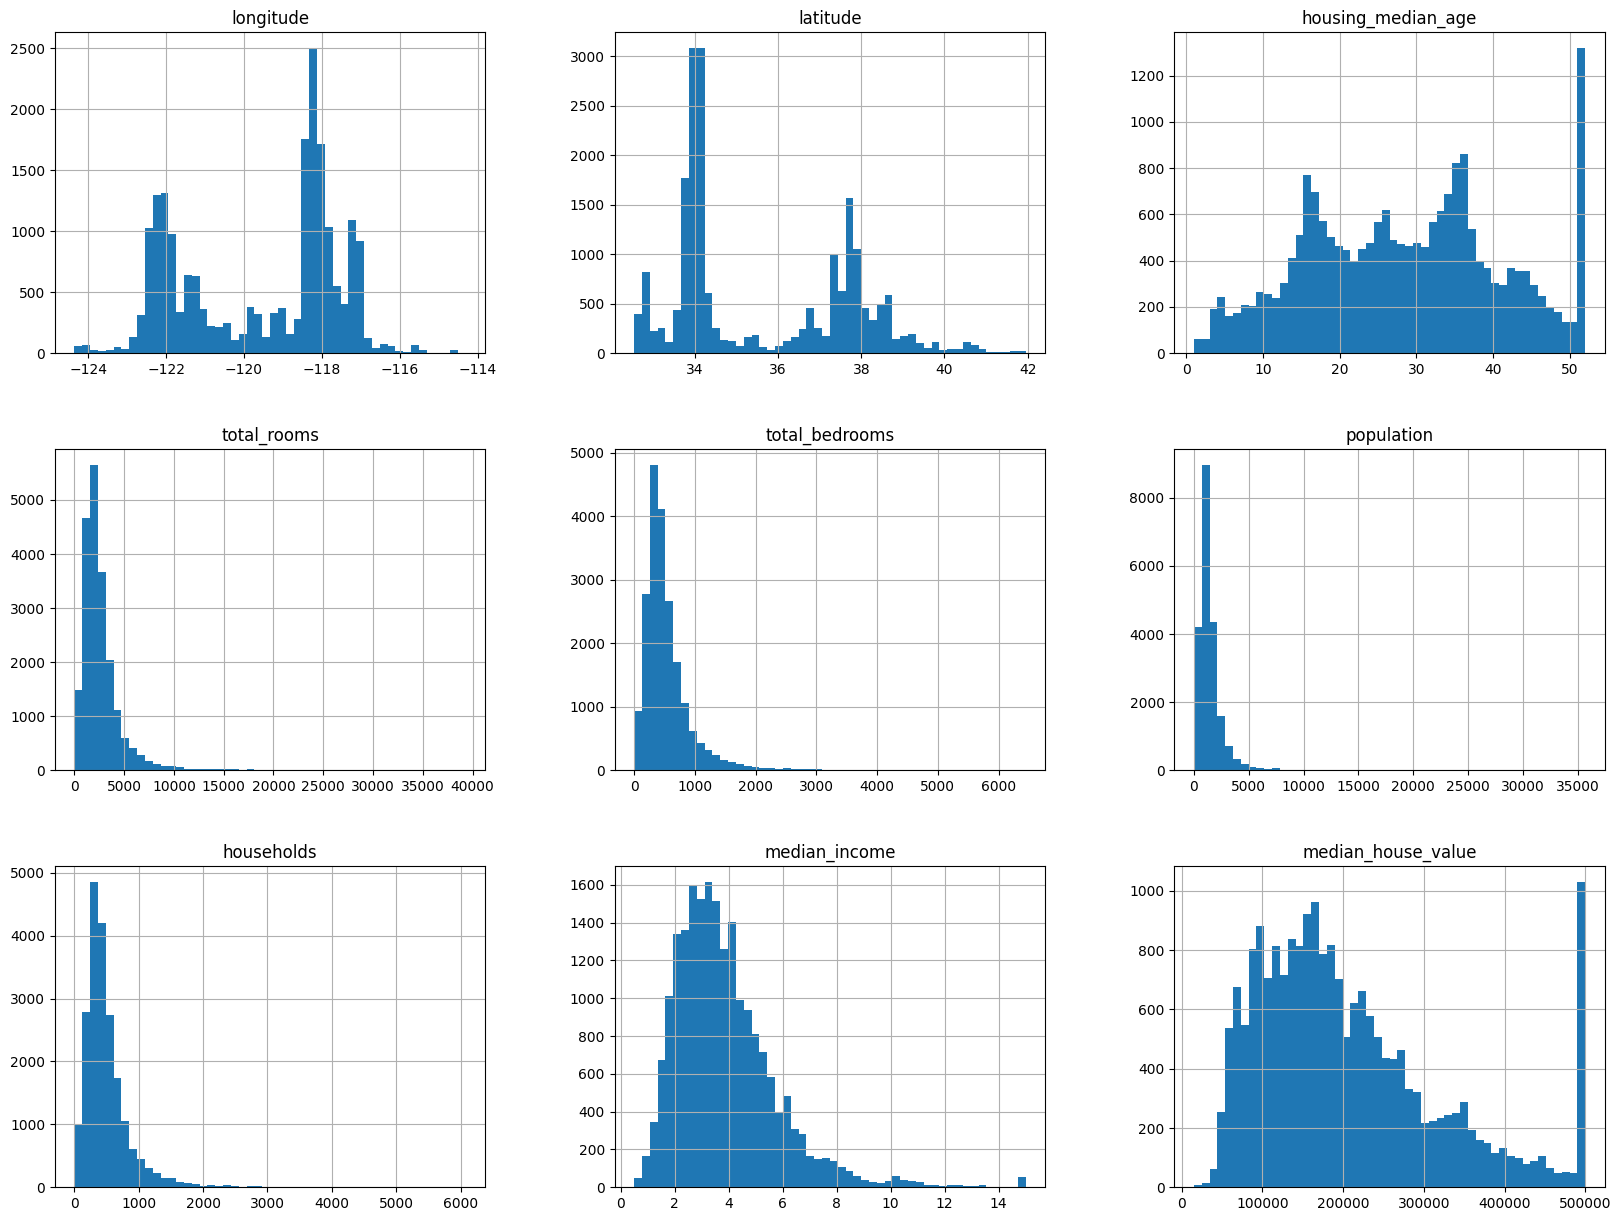

In [ ]:
housing.hist(bins=50, figsize=(20, 15))
plt.show()

The previous histograms show the distribution of values of numeric features. For categorical features, there isn't any function that plots all the histograms at once.
We obtain information on a categorical feature by invoking the function $value\_counts()$ on the column corresponding to that feature.

<div class="alert alert-block alert-success">
    
**Question 5.** Execute the following cell and interpret the output of the function $value\_counts()$.

</div>

In [ ]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


Execute the following cell if you want to plot an histogram of the values of the categorical feature.

<Axes: >

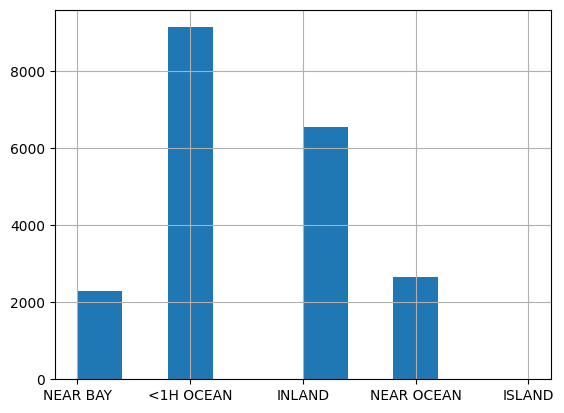

In [ ]:
housing['ocean_proximity'].hist()

We can also create new features if we need them. In the following cell we add a feature $income\_cat$ that applies a discretization of the feature $median\_income$ into 5 categories: category 1 corresponds to a median income between 0 and 1.5, category 2 corresponds to a median income between 1.5 and 3 and so on.

In [ ]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

## Create a test set

<div class="alert alert-block alert-success">
    
**Question 6.** Complete the following code in order split the dataset into a training and test set.

</div>

<div class="alert alert-block alert-info">

**Tip.** Use the function $train\_test\_split$ that you used in the first tutorial.
Unlike the first tutorial, the function returns two dataframes $train\_set$ and $test\_set$.

</div>

In [ ]:
# WRITE THE CODE HERE
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing)

In the following cell we compare the income category proportions in the input dataset against the proportions in the test set and we calculate the error on each income category (the **sampling bias**).

<div class="alert alert-block alert-success">
    
**Question 7.** What do you notice?

</div>

In [ ]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)


compare_props = pd.DataFrame({
    "Input_dataset": income_cat_proportions(housing),
    "Test_set": income_cat_proportions(test_set),
}).sort_index()
compare_props["Test set. %error"] = 100 * compare_props["Test_set"] / compare_props["Input_dataset"] - 100

compare_props

,Input_dataset,Test_set,Test set. %error
income_cat,,,
1,0.039826,0.037984,-4.622871
2,0.318847,0.318992,0.045586
3,0.350581,0.352713,0.608071
4,0.176308,0.175000,-0.741962
5,0.114438,0.115310,0.762066


A solution to the problem pointed out in the previous question is to resort to __stratified sampling__.
With stratified sampling, we create a test set that preserves the proportions of the income categories of the input dataset.
The following cell shows how to do it.

In [ ]:
strat_train_set, strat_test_set =\
train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42, shuffle=True)

If you run the following cell, you'll see by yourself that with stratified sampling the sampling bias is much lower than with random sampling.

In [ ]:
compare_props = pd.DataFrame({
    "Input_dataset": income_cat_proportions(housing),
    "Test_set": income_cat_proportions(test_set),
    "Stratified": income_cat_proportions(strat_test_set),
}).sort_index()
compare_props["Test set. %error"] = 100 * compare_props["Test_set"] / compare_props["Input_dataset"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Input_dataset"] - 100

compare_props

,Input_dataset,Test_set,Stratified,Test set. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.037984,0.039971,-4.622871,0.364964
2,0.318847,0.318992,0.318798,0.045586,-0.015195
3,0.350581,0.352713,0.350533,0.608071,-0.013820
4,0.176308,0.175000,0.176357,-0.741962,0.027480
5,0.114438,0.115310,0.114341,0.762066,-0.084674


<div class="alert alert-block alert-info">

Always consider using stratified sampling when you need to maintain in the test set the same value distributions of a feature as in the whole dataset.
**Caveat.** In this example the numeric variable has been artificially transformed into a categorical one. This allowed us to do stratified sampling. If we only have numeric variables, then the only available option is to resort to random sampling.

</div>

We're now going to analyze the data in more depth. For this task, we **set aside the test set** and we **only focus on the training set**.

At this stage, it would be tempting to use the whole dataset in order to analyze the data. However, if we find some interesting patterns on the whole dataset and we use them to train a machine learning model, the evaluation on the test set would definitely be biased (this is called **data snooping bias**). The test set must be treated as a set of data that we know virtually nothing about.

Since we're going to play with the training set, it is more prudent to make a copy of it.

In [ ]:
housing_copy = strat_train_set.copy()

## Looking for correlations

Since the dataset is not too big, we can compute the __correlation matrix__, where each cell contains the standard correlation coefficient (a.k.a., Pearson's $r$) between two features.

In [ ]:
corr_matrix = housing_copy.corr()

ValueError: could not convert string to float: 'INLAND'

By executing the following cell, you obtain the correlation coefficient of each feature with $median\_house\_value$, the target variable that we need to predict.

<div class="alert alert-block alert-success">
    
**Question 8.** Comment the result.

</div>

In [ ]:
corr_matrix["median_house_value"].sort_values(ascending=False)

NameError: name 'corr_matrix' is not defined

In the following cell, we plot the correlation between the most important features, as revealed by the correlation analysis above. The following code produces a matrix $S$, where each row and column corresponds to a feature. The cell $M[r, c]$ contains the plot of the correlation between features $r$ and $c$; the cell $M[r, r]$ contains the histogram of the values of $r$.

We can zoom in the correlation between $median\_income$ and $median\_house\_value$.

<div class="alert alert-block alert-success">

__Question 9.__ Is there anything that strikes you in this plot?

</div>

In [ ]:
housing_copy.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)

## Feature engineering

While analyzing the data, we might want to __create new features__ that are obtained as a combination of the existing ones. This is called __feature engineering__.
In our example, we might notice that there isn't any feature that gives an indication of the surface of a house; we do have the feature $total\_rooms$, but its values indicate the total number of rooms in a district, and gives no indication as to the surface of a house.

<div class="alert alert-block alert-success">

__Question 10.__ Propose a new feature that uses the feature _total_rooms_ in combination with another feature to have an indication of the surface of a house.

</div>

In [ ]:
# WRITE THE CODE HERE
housing_copy["rooms_per_household"] = housing_copy["total_rooms"]/housing_copy["households"]

<div class="alert alert-block alert-success">

__Question 11.__ Run the correlation analysis again and see if the new feature is useful.

</div>

In [ ]:
# WRITE THE CODE HERE
corr_matrix = housing_copy.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

Another information that is missing is that we don't have any indication of the number of rooms that are used as bedrooms; so, we can compute the ratio between $total\_bedrooms$ and $total\_rooms$. We'll call this new feature $bedrooms\_per\_room$.

<div class="alert alert-block alert-success">
    
Run the following cell and look at the correlation of the new feature with the target variable.

</div>

In [ ]:
housing_copy["bedrooms_per_room"] = housing_copy["total_bedrooms"]/housing_copy["total_rooms"]

corr_matrix = housing_copy.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

The new feature has a weak negative correlation with the target variable. It seems that houses that have a lower bedroom/room ratio tend to be more expensive.

## Transforming the data for training and testing

We first define a function $create\_matrices()$ that takes in two dataframes, one containing the training set the other containing the test set, and returns the matrices $X\_train$, $y\_train$, $X\_test$, $y\_test$.

In [ ]:
def create_matrices(train_set, test_set):

    '''Function that creates the matrices X_train, y_train, X_test, y_test that are used to train and
    test machine learning algorithms.

    Parameters
    ----------
        train_set : Dataframe.
            The training set (containing both the features and the target variable).
        test_set : Dataframe.
            The test set (containing both the features and the target variable).

    Returns
    -------
        A tuple (X_train, y_train, X_test, y_test).
        All elements of the tuple are Dataframes.
        X_train contains the values of all the features (without the target variable) of the training instances.
        y_train contains the values of the target variable of the training instances.
        X_test contains the values of all the features (without the target variable) of the test instances.
        y_test contains the values of the target variable of the test instances.
    '''

    X_train = train_set.drop("median_house_value", axis=1)
    y_train = train_set["median_house_value"].copy()

    X_test = test_set.drop("median_house_value", axis=1)
    y_test = test_set["median_house_value"].copy()
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = create_matrices(strat_train_set, strat_test_set)

Let's now focus on the **transformation of the numerical features** before training and testing.

In the first tutorial, we've seen the use of **pipelines** to specify data transformations prior to training and testing. All components, with the exception of the last one, must be **transformers**.
In our case, we need transformers to:

1. Scale the numerical features.
2. Imputing missing values.
3. Adding the two features $rooms\_per\_household$ and $bedrooms\_per\_room$.

We already know that *Scikit-learn* provides transformers for the first two actions; **we need to define a custom transformer** to add the two new features.

This is done in the following cell.

We define a new class called $FeatureEngineering$ that inherits from $BaseEstimator$ and $TransformerMixin$, two classes defined in *Scikit-learn*. The new class has two boolean variables:

* $add\_bedrooms\_per\_room$: we set it to $True$ if we intend to add the feature $bedrooms\_per\_room$.

* $add\_rooms\_per\_household$: we set it to $True$ if we intend to add the feature $rooms\_per\_household$.

When we create an instance of this transformer, we can choose whether to add one of the two features, both or none. This way, we can rapidly test different combinations to see their impact on the prediction error.

<div class="alert alert-block alert-info">
Any transformer must implement the functions $fit()$ and $transform()$.

* The function $fit()$ computes some values based on the values of the features of the training set. The computed values are then used by the $transform()$ function to actually transform the data. If no value must be computed at training time, $fit()$ returns $self$ (that means that the function does nothing).

* The function $transform()$ transforms the input data, possibly using the value(s) computed by the function $fit()$.

</div>

Since the transformation consists in adding two new features, the function $fit()$ doesn't need to compute anything on the training set; the transformations are implemented in the function $transform()$.


In [ ]:
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin


class FeatureEngineering(BaseEstimator, TransformerMixin):
    '''Defines a transformer to add two new features to the dataset.
    '''

    def __init__(self, add_bedrooms_per_room=True, add_rooms_per_household=True):
        ''' The constructor of this class.

        Parameters
        ----------
            add_bedrooms_per_room : boolean
                Set to True if you want to add the feature bedrooms_per_room (default: True).
            add_rooms_per_household : boolean
                Set to True if you want to add the feature rooms_per_household (default:True).

        '''
        self.add_bedrooms_per_room = add_bedrooms_per_room
        self.add_rooms_per_household = add_rooms_per_household


    def fit(self, X, y=None):
        ''' Function invoked on the training instances to compute some values that
        will be used by the function tranform. In this case, the function does nothing.

        Parameters
        ----------
            X : {array-like, sparse matrix}
                The values of the features of the training instances.
            y : array-like
                The values of the target variable of the training instances.

        Returns
        -------
            self
                An instance of self.
        '''
        return self

    def transform(self, X, y=None):

        '''Transforms the input data.

        Parameters
        ----------
            X : {array-like, sparse matrix}
                The values of the features of the input instances.
            y : array-like
                The values of the target variable of the input instances.

        Returns
        -------
            Numpy array
                The input instances with the new features.

        '''

        total_rooms_idx, total_bedrooms_idx, households_idx = 3, 4, 6

        rooms_per_household = X[:, total_rooms_idx]/X[:, households_idx]
        bedrooms_per_room = X[:, total_bedrooms_idx]/X[:, total_rooms_idx]

        if self.add_bedrooms_per_room and self.add_rooms_per_household:
            return np.c_[X, rooms_per_household, bedrooms_per_room]
        elif self.add_bedrooms_per_room:
            return np.c_[X, bedrooms_per_room]
        elif self.add_rooms_per_household:
            return np.c_[X, rooms_per_household]
        else:
            return np.c_[X]

<div class="alert alert-block alert-success">

__Question 12.__ Create a new pipeline called $num\_pipeline$ that:

1. Impute the missing values by using univariate median imputation as a strategy.

2. Adds the two features $bedrooms\_per\_room$ and $rooms\_per\_household$.

3. Standardize the values of the features.


</div>

In [ ]:
# WRITE THE CODE HERE


### Encoding categorical features

The pipeline that we created above will be applied to the numerical features, but we also have a categorical feature in our dataset named $ocean\_proximity$. Since most machine learning algorithms work with numeric features, it is necessary to transform the values of $ocean\_proximity$ into numbers.

We use a strategy called __one-hot encoding__. This creates one binary feature per category; in our case, we'll have 5 additional features. For a given instance, the feature 'INLAND' will have the value 1 if the corresponding value of the feature _ocean_proximity_ is 'INLAND', 0 otherwise.

<div class="alert alert-block alert-info">

We can apply one-hot encoding in *Scikit-learn* by using the transformer [sklearn.preprocessing.OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

</div>

In the following cell, we define a new transformer with $ColumnTransformer$ that applies the pipeline $num\_pipeline$ to the numeric features and the transformer $OneHotEncoder$ to the categorical feature.

<div class="alert alert-block alert-info">

In version 0.20, *Scikit-learn* introduced [sklearn.compute.ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) to create a new transformer as a combination of other transformers.

</div>


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# We get the list of the numerical features.
numeric_features = list(X_train.drop("ocean_proximity", axis=1))

# The only categorical feature.
categorical_features = ["ocean_proximity"]

# The new transformer that applies num_pipeline to the numeric features and
# OneHotEncoder on the categorical features.
housing_data_transformer = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", OneHotEncoder(), categorical_features)
])

We're now ready to train and test a machine learning model.

## Training and testing

<div class="alert alert-block alert-success">

__Question 13.__ Complete the code of function $train\_test\_linear\_regressor$ that trains and tests a linear regression model. The function will print the RMSE of the predictions on the test set. Call the function on the training and test set obtained previously ($X\_train$, $y\_train$, $X\_test$, $y\_test$).

</div>

<div class="alert alert-block alert-warning">

As a linear regression algorithm, use [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) instead of *SGDRegressor*. In fact, the latter produces different models after each run, which might be confusing, especially if you intend to do the optional exercises.

</div>

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def train_test_linear_regressor(X_train, y_train, X_test, y_test):
    '''Trains and test a linear regression model on the given training and test set.
    The function prints the RMSE of the predictions on the test set.

    Parameters
    ----------
        X_train : {array-like, sparse matrix}
            The matrix with the values of the features of the training instances.
        y_train : array-like
            The vector  with the values of the target variable of the training instances.
        X_test : {array-like, sparse matrix}
            The matrix with the values of the features of the test instances.
        y_test : array-like
            The vector  with the values of the target variable of the test instances.

    '''

    ##################### COMPLETE THE CODE HERE #####################


    ###############################################################

train_test_linear_regressor(X_train, y_train, X_test, y_test)

<div class="alert alert-block alert-success">

__Question 14.__ What happens if you don't add the features $bedrooms\_per\_room$ and $rooms\_per\_household$?
What happens if you only add one of them? Go back to the definition of $num\_pipeline$ and change the values of its boolean parameters accordingly. Then retrain and test a linear regression model.

</div>

At some point, we've seen that there are many instances for which the value of $median\_house\_value$ is 500,000. This means that the target variable is capped at that value. In other words, the median house value for many districts is higher than 500,000, but for some reason, its value has been brought down to 500,000. This might be a problem, since the machine learning algorithm will learn that the median house price will never be more than 500,000.

In the next cell, we create a new train and test set, where the instances whose value of $median\_house\_value$ is 500,000 are removed. The code displays the scatter plots of $median\_income$ against $median\_house\_value$ when keeping all instances (in red) and when removing the instances with $median\_house\_value$ = 500 (in blue).

<div class="alert alert-block alert-success">

__Question 15.__ What is the difference between the two scatter plots?

</div>

In [ ]:
strat_train_set.plot(kind="scatter", x="median_income", y="median_house_value", title="All instances", alpha=0.1, c="red")

strat_train_set_new = strat_train_set[strat_train_set["median_house_value"]<500000]
strat_test_set_new = strat_test_set[strat_test_set["median_house_value"]<500000]

strat_train_set_new.plot(kind="scatter", x="median_income", y="median_house_value", title="Instances < 500000", alpha=0.1)

<div class="alert alert-block alert-success">

__Question 16.__ Write the code to train and test a linear regression model on $strat\_train\_set\_new$ and $strat\_test\_set\_new$. What can you say about the prediction error, compared with what you obtained before?

</div>

In [ ]:
# WRITE THE CODE HERE


<div class="alert alert-block alert-success">

**Solution.** After removing those particular instances, we decidedly reduced the prediction error.

</div>